# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
Bhagat Singh was one of the most influential revolutionaries of the Indian independence movement. He believed that freedom could only be achieved through courage, sacrifice, and determination. From a young age, he was inspired by stories of patriotism and resistance against colonial rule. He devoted his life to the service of the nation and became a symbol of bravery.

Subhas Chandra Bose was a charismatic leader who inspired millions of Indians. He believed that freedom was not given but earned through struggle and determination. Bose organized the Indian National Army and encouraged people to fight for independence. His famous slogan, "Give me blood, and I will give you freedom," continues to inspire generations.

Mahatma Gandhi led India’s freedom movement through nonviolent resistance. He promoted truth, peace, and self-discipline. Gandhi believed that lasting change could be achieved through moral courage and unity. His leadership united people from different backgrounds in the common cause of independence.

Dr. A.P.J. Abdul Kalam was a scientist, teacher, and visionary leader. He played a major role in India's missile and space programs. Kalam inspired young people to dream big and work hard. He believed that education, innovation, and perseverance were the keys to national development.

Swami Vivekananda was a spiritual leader who emphasized the importance of self-confidence, character, and service to humanity. His speeches inspired people to believe in their inner strength. He encouraged youth to develop discipline, knowledge, and compassion.

India is a nation with a rich history, diverse culture, and remarkable achievements. Throughout history, countless individuals have contributed to science, education, literature, and social reform. Their dedication and vision have helped shape the country's progress.

Success is achieved through consistent effort, learning, and resilience. Every challenge presents an opportunity to grow stronger and wiser. People who remain focused on their goals often overcome difficulties and achieve remarkable accomplishments.

Technology has transformed the modern world by improving communication, healthcare, transportation, and education. Artificial intelligence, machine learning, and data science are creating new opportunities for innovation. Students who continuously learn new skills can contribute to solving real-world problems.

Education empowers individuals to think critically and make informed decisions. Knowledge gained through study and experience helps people adapt to changing circumstances. Lifelong learning is essential for personal and professional growth.

Great leaders inspire others through their actions and values. They demonstrate integrity, responsibility, and commitment to a greater purpose. Their influence extends beyond their own achievements and motivates future generations to strive for excellence.
'''
print(corpus)


Bhagat Singh was one of the most influential revolutionaries of the Indian independence movement. He believed that freedom could only be achieved through courage, sacrifice, and determination. From a young age, he was inspired by stories of patriotism and resistance against colonial rule. He devoted his life to the service of the nation and became a symbol of bravery.

Subhas Chandra Bose was a charismatic leader who inspired millions of Indians. He believed that freedom was not given but earned through struggle and determination. Bose organized the Indian National Army and encouraged people to fight for independence. His famous slogan, "Give me blood, and I will give you freedom," continues to inspire generations.

Mahatma Gandhi led India’s freedom movement through nonviolent resistance. He promoted truth, peace, and self-discipline. Gandhi believed that lasting change could be achieved through moral courage and unity. His leadership united people from different backgrounds in the c

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 251
X shape: (402, 58)
y shape: (402,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

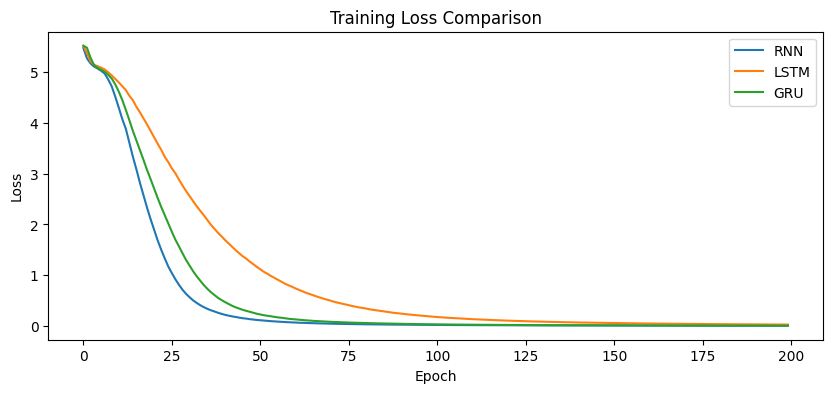

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "Bhagat singh was", 10))
print("LSTM:", generate_text(lstm_model, "Success is achieved", 10))
print("GRU :", generate_text(gru_model, "Great leaders inspire", 10))

RNN : Bhagat singh was one of the most influential revolutionaries of the indian independence
LSTM: Success is achieved through consistent effort learning and resilience every challenge presents an
GRU : Great leaders inspire others through their actions and values they demonstrate integrity responsibility


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**